In [1]:
import shutil
import os

project_folder = "/kaggle/working/Violence-detection"  # or your project folder path

# Check if it exists first
if os.path.exists(project_folder):
    shutil.rmtree(project_folder)
    print(f"Deleted project folder: {project_folder}")
else:
    print("Project folder does not exist.")

Project folder does not exist.


# 01_data_preparation_and_dataset_pipeline

In [2]:
import os
import shutil

# -----------------------------
# Base project path
# -----------------------------
BASE_DIR = "/kaggle/working/Violence-detection"
os.makedirs(BASE_DIR, exist_ok=True)

# -----------------------------
# Folder structure
# -----------------------------
folders = [
    "data/videos/train/Violence",
    "data/videos/train/NonViolence",
    "data/videos/val/Violence",
    "data/videos/val/NonViolence",
    "data/videos/test/Violence",
    "data/videos/test/NonViolence",
    "notebooks",
    "src/utils",
    "src/dataset",
    "outputs",
    "checkpoints",
    "figures",
    "logs",
    "app",
    "configs"
]

for f in folders:
    os.makedirs(os.path.join(BASE_DIR, f), exist_ok=True)

print("Folders, scripts!")

Folders, scripts!


## configs/config.py

In [3]:
import os
BASE_DIR = "/kaggle/working/Violence-detection"
os.makedirs(BASE_DIR, exist_ok=True)
# -----------------------------
# Create config.py
# -----------------------------
config_content = '''# Configuration for Violence Detection Project

import os

# =====================
# Paths
# =====================

BASE_DIR = "/kaggle/working/Violence-detection"
DATA_DIR = os.path.join(BASE_DIR, "data")
VIDEOS_DIR = os.path.join(DATA_DIR, "videos")

# =====================
# Video preprocessing
# =====================

NUM_FRAMES = 8
FRAME_SIZE = (160, 160) 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# =====================
# Dataset split
# =====================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# =====================
# DataLoader
# =====================

BATCH_SIZE = 4
NUM_WORKERS = 0
'''

with open(os.path.join(BASE_DIR, "configs/config.py"), "w") as f:
    f.write(config_content)
    
print("config file is ready!")


config file is ready!


In [4]:
import sys, os

BASE_DIR = "/kaggle/working/Violence-detection"

sys.path.append(BASE_DIR)  #  this is key
sys.path.append(os.path.join(BASE_DIR, "src"))

from configs.config import VIDEOS_DIR, NUM_FRAMES

## Phase 1 Notebook

In [5]:
import os
import shutil
import glob
from configs.config import BASE_DIR ,VIDEOS_DIR,  TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_SEED
import random
# 01_data_preparation_and_dataset_pipeline.ipynb
# Phase 1: Dataset Splitting and Preparation

# ----------------------------
# 0️ Setup
# ---------------------------- for reproducibility
random.seed(RANDOM_SEED)

# ----------------------------
# 1️ Local merged dataset folder
# ------------------- ---------
# Suppose you merged all videos in:
LOCAL_MERGED_DIR = "/kaggle/input/datasets/messaoudiriham/merged-violence-dataset/Violence Detection Dataset"

# The folder structure is assumed like this:
# merged_dataset/Violence/*.mp4 or *.avi
# merged_dataset/NonViolence/*.mp4 or *.avi

violence_videos = [os.path.join(LOCAL_MERGED_DIR, "Violence", f)
                    for f in os.listdir(os.path.join(LOCAL_MERGED_DIR, "Violence"))
                    if f.lower().endswith((".mp4", ".avi"))]

nonviolence_videos = [os.path.join(LOCAL_MERGED_DIR, "NonViolence", f)
                      for f in os.listdir(os.path.join(LOCAL_MERGED_DIR, "NonViolence"))
                      if f.lower().endswith((".mp4", ".avi"))]

print(f"Violence videos: {len(violence_videos)}")
print(f"NonViolence videos: {len(nonviolence_videos)}")

# ----------------------------
# 2️ Shuffle and split
# ----------------------------
def split_list(videos, train_ratio, val_ratio, test_ratio):
    random.shuffle(videos)
    n_total = len(videos)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)
    n_test  = n_total - n_train - n_val
    train = videos[:n_train]
    val   = videos[n_train:n_train+n_val]
    test  = videos[n_train+n_val:]
    return train, val, test

violence_train, violence_val, violence_test = split_list(violence_videos, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
nonviolence_train, nonviolence_val, nonviolence_test = split_list(nonviolence_videos, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

# ----------------------------
# 3️ Copy to structured folders
# ----------------------------
def copy_videos(video_list, split_name, label_name):
    dest_dir = os.path.join(VIDEOS_DIR, split_name, label_name)
    os.makedirs(dest_dir, exist_ok=True)
    for src in video_list:
        shutil.copy(src, dest_dir)

# Violence
copy_videos(violence_train, "train", "Violence")
copy_videos(violence_val,   "val",   "Violence")
copy_videos(violence_test,  "test",  "Violence")

# NonViolence
copy_videos(nonviolence_train, "train", "NonViolence")
copy_videos(nonviolence_val,   "val",   "NonViolence")
copy_videos(nonviolence_test,  "test",  "NonViolence")

print("Dataset split and copied to structured folders.")

# ----------------------------
# 4️ Verify counts
# ----------------------------
for split in ["train", "val", "test"]:
    v_count = len(os.listdir(os.path.join(VIDEOS_DIR, split, "Violence")))
    nv_count = len(os.listdir(os.path.join(VIDEOS_DIR, split, "NonViolence")))
    print(f"{split} - Violence: {v_count}, NonViolence: {nv_count}")

Violence videos: 3500
NonViolence videos: 3500
Dataset split and copied to structured folders.
train - Violence: 2450, NonViolence: 2450
val - Violence: 525, NonViolence: 525
test - Violence: 525, NonViolence: 525


In [6]:
for split in ["train", "val", "test"]:
    v_count = len(os.listdir(os.path.join(VIDEOS_DIR, split, "Violence")))
    nv_count = len(os.listdir(os.path.join(VIDEOS_DIR, split, "NonViolence")))
    print(f"{split} - Violence: {v_count}, NonViolence: {nv_count}")

train - Violence: 2450, NonViolence: 2450
val - Violence: 525, NonViolence: 525
test - Violence: 525, NonViolence: 525


## src/utils/video_utils.py

In [7]:
import os
from configs.config import BASE_DIR 
os.makedirs(BASE_DIR, exist_ok=True)
video_utils_content =''' # video utils for  Violence Detection Project
import cv2
import numpy as np
import torch
from configs.config import NUM_FRAMES, FRAME_SIZE, IMAGENET_MEAN, IMAGENET_STD

def load_video_frames(video_path, num_frames=NUM_FRAMES, resize=FRAME_SIZE):
    import cv2
    import numpy as np
    import torch
    from configs.config import IMAGENET_MEAN, IMAGENET_STD

    frames = []
    last_frame = np.zeros((resize[1], resize[0], 3), dtype=np.uint8)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️ Cannot open video: {video_path}")
        return torch.zeros((num_frames, 3, resize[1], resize[0]), dtype=torch.float)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"⚠️ Video has 0 frames: {video_path}")
        return torch.zeros((num_frames, 3, resize[1], resize[0]), dtype=torch.float)

    frame_idxs = np.linspace(0, max(total_frames-1,0), num_frames).astype(int)

    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret or frame is None:
            frame = last_frame
        else:
            try:
                # If grayscale, convert to RGB
                if frame.ndim == 2:
                    frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
                # If frame has wrong number of channels
                elif frame.shape[2] != 3:
                    frame = last_frame
                else:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, resize)
            except:
                frame = last_frame

        last_frame = frame
        frame = frame.astype(np.float16)/255.0
        frame = (frame - IMAGENET_MEAN)/IMAGENET_STD
        frame = np.transpose(frame, (2,0,1))
        frames.append(frame)

    cap.release()
    return torch.tensor(np.array(frames), dtype=torch.float)
    
    '''
with open(os.path.join(BASE_DIR , "src/utils/video_utils.py"),"w")as f:
    f.write(video_utils_content )

print("video utils file is ready!")



video utils file is ready!


In [8]:
import torch
import sys
sys.path.append("/kaggle/working/Violence-detection/src/utils")
from video_utils import load_video_frames  # from src/video_dataset.py

In [9]:
import importlib
import video_utils
importlib.reload(video_utils)
from video_utils import load_video_frames

In [10]:
from video_utils import load_video_frames

video_path = "/kaggle/working/Violence-detection/data/videos/train/Violence/V_1.mp4"
frames = load_video_frames(video_path)
print(frames.shape)  # should be [NUM_FRAMES, 3, 224, 224]

torch.Size([8, 3, 160, 160])


In [11]:
import os
import torch
from video_utils import load_video_frames  # your existing function

def filter_corrupted_videos(video_dir, label_name):
    video_list = []
    folder_path = os.path.join(video_dir, label_name)
    if not os.path.exists(folder_path):
        return []

    for f in os.listdir(folder_path):
        if not f.lower().endswith((".mp4",".avi")):
            continue
        path = os.path.join(folder_path, f)
        try:
            _ = load_video_frames(path, num_frames=1)  # fast check
            video_list.append((path, 1 if label_name=="Violence" else 0))
        except:
            print(f"⚠️ Skipping corrupted video: {path}")
    return video_list

# Prepare lists
train_videos = filter_corrupted_videos(os.path.join(VIDEOS_DIR,"train"),"Violence") + \
               filter_corrupted_videos(os.path.join(VIDEOS_DIR,"train"),"NonViolence")
val_videos   = filter_corrupted_videos(os.path.join(VIDEOS_DIR,"val"),"Violence") + \
               filter_corrupted_videos(os.path.join(VIDEOS_DIR,"val"),"NonViolence")
test_videos  = filter_corrupted_videos(os.path.join(VIDEOS_DIR,"test"),"Violence") + \
               filter_corrupted_videos(os.path.join(VIDEOS_DIR,"test"),"NonViolence")

print(f"Train: {len(train_videos)}, Val: {len(val_videos)}, Test: {len(test_videos)}")

Train: 4900, Val: 1050, Test: 1050


In [12]:
print(train_videos[0])
# ('/kaggle/working/Violence-detection/data/videos/train/Violence/V_1.mp4', 1)

('/kaggle/working/Violence-detection/data/videos/train/Violence/V_338.mp4', 1)


# cached videos 

In [13]:
import torch
import os
from video_utils import load_video_frames

def cache_videos(video_list, cache_dir, num_frames=NUM_FRAMES):
    import os, torch
    os.makedirs(cache_dir, exist_ok=True)
    cached_list = []

    for i, (path, label) in enumerate(video_list):
        if i % 100 == 0:
            print(f"Processing {i}/{len(video_list)}")

        name = os.path.splitext(os.path.basename(path))[0] + ".pt"
        cached_path = os.path.join(cache_dir, name)

        if not os.path.exists(cached_path):
            try:
                tensor = load_video_frames(path, num_frames=num_frames).half()
                torch.save(tensor, cached_path)

                # Verify tensor
                loaded = torch.load(cached_path)
                if loaded.shape != tensor.shape:
                    print(f"⚠️ Corrupted cache: {cached_path}")
                    os.remove(cached_path)  # delete bad file
                    continue

                # Delete ONLY if save is successful
                os.remove(path)

            except Exception as e:
                print(f"❌ Error processing {path}: {e}")
                continue

        cached_list.append((cached_path, label))

    return cached_list
    
cache_base = os.path.join(BASE_DIR,"data/video_cache")
train_cache = os.path.join(cache_base,"train")
val_cache   = os.path.join(cache_base,"val")
test_cache  = os.path.join(cache_base,"test")

train_cached = cache_videos(train_videos, train_cache)
val_cached   = cache_videos(val_videos, val_cache)
test_cached  = cache_videos(test_videos, test_cache)

Processing 0/4900
Processing 100/4900
Processing 200/4900
Processing 300/4900
Processing 400/4900
Processing 500/4900
Processing 600/4900
Processing 700/4900
Processing 800/4900
Processing 900/4900
Processing 1000/4900
Processing 1100/4900
Processing 1200/4900
Processing 1300/4900
Processing 1400/4900
Processing 1500/4900
Processing 1600/4900
Processing 1700/4900
Processing 1800/4900
Processing 1900/4900
Processing 2000/4900
Processing 2100/4900
Processing 2200/4900
Processing 2300/4900
Processing 2400/4900
Processing 2500/4900
Processing 2600/4900
Processing 2700/4900
Processing 2800/4900
Processing 2900/4900
Processing 3000/4900
Processing 3100/4900
Processing 3200/4900
Processing 3300/4900
Processing 3400/4900
Processing 3500/4900
Processing 3600/4900
Processing 3700/4900
Processing 3800/4900
Processing 3900/4900
Processing 4000/4900
Processing 4100/4900


[h264 @ 0xec89740] mb_type 104 in P slice too large at 98 31
[h264 @ 0xec89740] error while decoding MB 98 31


Processing 4200/4900
Processing 4300/4900
Processing 4400/4900
Processing 4500/4900
Processing 4600/4900


[h264 @ 0xec89fc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0xec89fc0] error while decoding MB 98 31


Processing 4700/4900
Processing 4800/4900
Processing 0/1050
Processing 100/1050
Processing 200/1050
Processing 300/1050
Processing 400/1050
Processing 500/1050
Processing 600/1050
Processing 700/1050
Processing 800/1050
Processing 900/1050
Processing 1000/1050
Processing 0/1050
Processing 100/1050
Processing 200/1050
Processing 300/1050
Processing 400/1050
Processing 500/1050
Processing 600/1050
Processing 700/1050
Processing 800/1050
Processing 900/1050
Processing 1000/1050


In [14]:
# ===============================
# 🔍 CHECK DATA LEAKAGE
# ===============================

def get_names(cached_list):
    return set([os.path.basename(p) for p, _ in cached_list])

train_names = get_names(train_cached)
val_names   = get_names(val_cached)
test_names  = get_names(test_cached)

print("Train ∩ Val:", len(train_names & val_names))
print("Train ∩ Test:", len(train_names & test_names))
print("Val ∩ Test:", len(val_names & test_names))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [15]:
# ===============================
# ⚖️ CHECK CLASS BALANCE
# ===============================

def check_balance(cached_list, name):
    labels = [label for _, label in cached_list]
    violence = sum(labels)
    non_violence = len(labels) - violence
    print(f"{name} → Violence: {violence}, NonViolence: {non_violence}")

check_balance(train_cached, "Train")
check_balance(val_cached, "Val")
check_balance(test_cached, "Test")

Train → Violence: 2450, NonViolence: 2450
Val → Violence: 525, NonViolence: 525
Test → Violence: 525, NonViolence: 525


In [16]:
# ===============================
# 📁 VERIFY FILE COUNT
# ===============================

def count_files(folder):
    return len([f for f in os.listdir(folder) if f.endswith(".pt")])

print("Train cached:", count_files(train_cache))
print("Val cached:", count_files(val_cache))
print("Test cached:", count_files(test_cache))

Train cached: 4900
Val cached: 1050
Test cached: 1050


In [17]:
import os

cache_base = "/kaggle/working/Violence-detection/data/video_cache"


def count_pt_files(folder):
    total = 0
    for root, _, files in os.walk(folder):
        total += sum(1 for f in files if f.endswith(".pt"))
    return total

for split in ["train", "val", "test"]:
    path = os.path.join(cache_base, split)
    count = count_pt_files(path)

    print(f"{split.upper()} → Found: {count} ")

TRAIN → Found: 4900 
VAL → Found: 1050 
TEST → Found: 1050 


## src/dataset/CachedVideoDataset.py

In [18]:
import os
from configs.config import BASE_DIR 
os.makedirs(BASE_DIR, exist_ok=True)
video_dataset_content =''' # video dataset for  Violence Detection Project

import os,sys
import torch
sys.path.append("/kaggle/working/Violence-detection/src/utils")
from torch.utils.data import Dataset
from video_utils import load_video_frames

class CachedVideoDataset(Dataset):
    def __init__(self, video_list, transform=None):
        self.video_list = video_list
        self.transform = transform

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        path, label = self.video_list[idx]
        video_tensor = torch.load(path)
        if self.transform:
            video_tensor = self.transform(video_tensor)
        return video_tensor, torch.tensor(label, dtype=torch.float), path
        '''
        
with open(os.path.join(BASE_DIR, "src/dataset/video_dataset.py"), "w") as f:
    f.write(video_dataset_content )
print("video dataset file is ready!")


video dataset file is ready!


In [19]:
import torch
import sys
sys.path.append("/kaggle/working/Violence-detection/src/dataset")
from video_dataset import CachedVideoDataset  # from src/video_dataset.py

In [20]:
import importlib
import video_dataset
importlib.reload(video_dataset)
from video_dataset import CachedVideoDataset

In [21]:
import os

BASE_DIR = "/kaggle/working/Violence-detection/"

total_files = 0
total_size = 0

for root, dirs, files in os.walk(BASE_DIR):
    total_files += len(files)
    total_size += sum(os.path.getsize(os.path.join(root, f)) for f in files)

print(f"Files in working dir: {total_files}")
print(f"Total size: {total_size/1e9:.2f} GB")

Files in working dir: 7006
Total size: 8.61 GB


# 02_vit_model_baseline

In [22]:
import os
import sys
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [23]:
import sys, os

BASE_DIR = "/kaggle/working/Violence-detection"

sys.path.append(BASE_DIR)  # 👈 this is key
sys.path.append(os.path.join(BASE_DIR, "src"))

from configs.config import VIDEOS_DIR, BATCH_SIZE, NUM_WORKERS, NUM_FRAMES

In [24]:
##this use after creating the files of utils and datasets and before iport the functions 
import sys
sys.path.append("/kaggle/working/Violence-detection/src/dataset")
sys.path.append("/kaggle/working/Violence-detection/src/utils")
from video_dataset import CachedVideoDataset  # from src/video_dataset.py
from video_utils import load_video_frames  # from utils/video_utils.py

##  Verify Dataset & DataLoader

In [25]:
# ===============================
# 1️⃣ Verify Dataset & DataLoader
# ===============================
# Train, Val
train_dataset = CachedVideoDataset(train_cached)
val_dataset   = CachedVideoDataset(val_cached)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Sample batch check:")
for videos, labels, paths in train_loader:
    print(videos.shape, labels, paths[:3])
    break

Sample batch check:
torch.Size([4, 8, 3, 160, 160]) tensor([0., 1., 0., 1.]) ('/kaggle/working/Violence-detection/data/video_cache/train/file_001907.pt', '/kaggle/working/Violence-detection/data/video_cache/train/file_002088.pt', '/kaggle/working/Violence-detection/data/video_cache/train/NV_38.pt')


## Simple ViT Model for Video

In [28]:
import torch
import torch.nn as nn
import torchvision.models as models

class ResNetVideoClassifierCPU(nn.Module):
    def __init__(self, num_classes=1, backbone="mobilenet_v2", freeze_backbone=True):
        super().__init__()

        # ✅ Use a lightweight backbone for CPU
        if backbone == "mobilenet_v2":
            resnet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features
            self.feature_dim = 1280
        else:  # default ResNet18
            resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            resnet = nn.Sequential(*list(resnet.children())[:-1])
            self.feature_dim = 512

        self.feature_extractor = resnet

        # Freeze backbone if needed
        if freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x):
        B, F, C, H, W = x.shape

        # Merge batch and frames
        x = x.view(B * F, C, H, W)

        features = self.feature_extractor(x)  # (B*F, feature_dim, 1, 1) or (B*F, feature_dim, H', W')
        features = features.mean([2, 3]) if features.ndim == 4 else features.view(B, F, self.feature_dim)  # global avg pool
        features = features.view(B, F, -1)

        # Temporal pooling
        features = features.mean(dim=1)

        logits = self.classifier(features).squeeze(1)
        return logits

### Define Loss, Optimizer, Device

In [29]:
# ===============================
# 3️⃣ Define Loss, Optimizer, Device
# ===============================

device = "cpu"
model = ResNetVideoClassifierCPU(num_classes=1, backbone="mobilenet_v2", freeze_backbone=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=3e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s]


##  Training & Validation Loop

In [33]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for videos, labels, _ in dataloader:
        videos, labels = videos.to(device).float(), labels.to(device)
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * videos.size(0)
    return total_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for videos, labels, _ in dataloader:
            videos, labels = videos.to(device).float(), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * videos.size(0)
            preds = torch.sigmoid(outputs) > 0.45
            correct += (preds == labels.byte()).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

###  Run Baseline Training

In [34]:
# ===============================
# 5️⃣ Run Baseline Training
# ===============================


NUM_EPOCHS = 8  # baseline small run
best_val_acc = 0

# Lists to store metrics
train_losses = []
val_losses = []
val_accuracies = []

# Inside your training loop, after each epoch:
for epoch in range(1, NUM_EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save checkpoint if best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(BASE_DIR, "checkpoints", "vit_baseline_ResNet.pth"))
        print("✅ Checkpoint saved.")

Epoch 1 | Train Loss: 0.5767 | Val Loss: 0.4308 | Val Acc: 0.8152
✅ Checkpoint saved.
Epoch 2 | Train Loss: 0.5071 | Val Loss: 0.4003 | Val Acc: 0.8257
✅ Checkpoint saved.
Epoch 3 | Train Loss: 0.4819 | Val Loss: 0.3696 | Val Acc: 0.8343
✅ Checkpoint saved.
Epoch 4 | Train Loss: 0.4762 | Val Loss: 0.3795 | Val Acc: 0.8476
✅ Checkpoint saved.
Epoch 5 | Train Loss: 0.4649 | Val Loss: 0.3604 | Val Acc: 0.8486
✅ Checkpoint saved.
Epoch 6 | Train Loss: 0.4603 | Val Loss: 0.3544 | Val Acc: 0.8552
✅ Checkpoint saved.
Epoch 7 | Train Loss: 0.4604 | Val Loss: 0.3479 | Val Acc: 0.8514
Epoch 8 | Train Loss: 0.4387 | Val Loss: 0.3432 | Val Acc: 0.8438


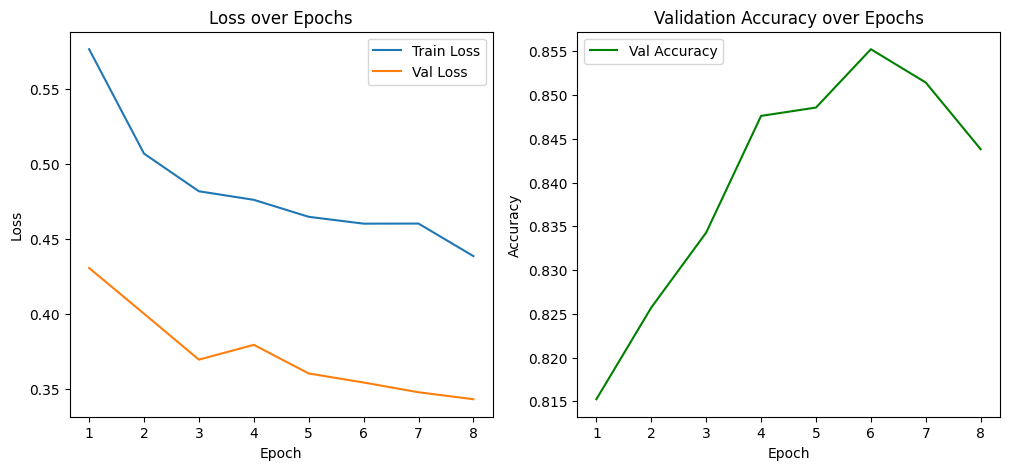

In [35]:
# ===============================
# Plot Training & Validation Metrics
# ===============================
import matplotlib.pyplot as plt

# Ensure you have these lists from training
# train_losses, val_losses, val_accuracies

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, label="Val Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()

plt.show()

## Load Checkpoint & Test 

In [ ]:
# ===============================
# 6️⃣ Test Skeleton
# ===============================

test_dataset  = CachedVideoDataset(test_cached)

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Sample batch check:")
for videos, labels, paths in train_loader:
    print(videos.shape, labels, paths[:3])
    break
model.load_state_dict(torch.load("/kaggle/input/models/messaoudiriham/vit-resnet-model/pytorch/default/2/vit_baseline_ResNet2.pth",map_location='cpu'))
model.to(device)
model.eval()

test_correct = 0
with torch.no_grad():
    for videos, labels, _ in test_loader:
        videos = videos.to(device).float()
        labels = labels.to(device)
        outputs = model(videos)
        preds = torch.sigmoid(outputs) > 0.45
        test_correct += (preds == labels.byte()).sum().item()

test_acc = test_correct / len(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Sample batch check:
torch.Size([4, 8, 3, 160, 160]) tensor([0., 1., 0., 0.]) ('/kaggle/working/Violence-detection/data/video_cache/train/file_001879.pt', '/kaggle/working/Violence-detection/data/video_cache/train/fi133_xvid.pt', '/kaggle/working/Violence-detection/data/video_cache/train/file_001899.pt')


In [37]:
# ===============================
# 📊 CONFUSION MATRIX CHECK
# ===============================

tp, tn, fp, fn = 0, 0, 0, 0

model.eval()
with torch.no_grad():
    for videos, labels, _ in test_loader:
        videos = videos.to(device).float()
        labels = labels.to(device)

        outputs = model(videos)
        preds = (torch.sigmoid(outputs) > 0.45).int()

        for p, l in zip(preds, labels):
            if p == 1 and l == 1: tp += 1
            elif p == 0 and l == 0: tn += 1
            elif p == 1 and l == 0: fp += 1
            elif p == 0 and l == 1: fn += 1

print(f"TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}")

TP:440, TN:437, FP:88, FN:85


In [38]:
precision = tp / (tp + fp + 1e-8)
recall    = tp / (tp + fn + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.8333
Recall:    0.8381
F1-score:  0.8357


In [41]:
import os
import torch

# Save model in a folder
checkpoint_dir = "/kaggle/working/vit_model"
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(checkpoint_dir, "vit_baseline_ResNet2.pth"))

In [42]:
import torch

file1 = "/kaggle/working/Violence-detection/checkpoints/vit_baseline_ResNet.pth"
file2 = "/kaggle/working/vit_model/vit_baseline_ResNet2.pth"

state1 = torch.load(file1)
state2 = torch.load(file2)

# Compare all keys
all_same = all(torch.equal(state1[k], state2[k]) for k in state1)
print("Are the weights identical?", all_same)

Are the weights identical? True
